In [5]:
import networkx as nx
import numpy as np

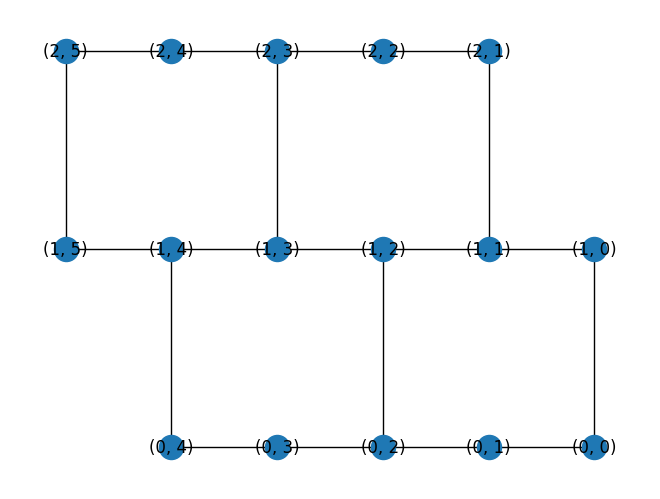

In [2]:
cols = 2
rows = 2
hex = nx.hexagonal_lattice_graph(cols, rows)
nx.draw(hex, pos={node: (-node[1], node[0]) for node in hex.nodes}, with_labels=True)

In [3]:
cols = 2
rows = 2
hex = nx.hexagonal_lattice_graph(cols, rows)
coupling_graph = nx.Graph()
counter = 0
mapping = {}
index_to_name_mapping = {}

a_nodes = []
b_nodes = []
a_edges = []
b_edges = []

for node in hex.nodes:
    coupling_graph.add_node(counter)
    mapping[node] = counter
    index_to_name_mapping[counter] = node
    counter += 1
for edge in hex.edges:
    coupling_graph.add_node(counter)
    
    if edge[0][0] != edge[1][0]:
        if (edge[0][0] == 0 and edge[0][1] == 2*cols): # or (edge[0][0] == rows-1 and edge[0][1] == 2*cols) : leave the last one out
            pass
        # Even row
        elif edge[0][0] % 2 == 0 and edge[0][1] % 4 == 2 and not edge[0][1] == 0:
            a_nodes.append(edge)
        # Even row
        elif edge[0][0] % 2 == 0 and edge[0][1] % 4 == 0 and not edge[0][1] == 0:
            b_nodes.append(edge)
        # Odd row
        elif edge[0][0] % 2 == 1 and edge[0][1] % 4 == 1 and not edge[0][1] == 2*cols+1:
            a_nodes.append(edge)
        # Odd row
        elif edge[0][0] % 2 == 1 and edge[0][1] % 4 == 3 and not edge[0][1] == 2*cols+1:
            b_nodes.append(edge)
            
    
    mapping[edge] = counter
    mapping[edge[::-1]] = counter
    index_to_name_mapping[counter] = edge
    counter += 1
    
    
for node in hex.nodes:
    for edge in hex.edges(node):
        coupling_graph.add_edge(mapping[node], mapping[edge])

In [4]:
line_node_counters = [mapping[((0, 2*cols), (1, 2*cols))]]

for col_idx in range(2*rows,0,-1):
    line_node_counters.append(mapping[(0, col_idx)])
    line_node_counters.append(mapping[((0, col_idx),(0, col_idx-1))])
line_node_counters.append(mapping[(0, 0)])
line_node_counters.append(mapping[((0, 0), (1, 0))])

for row_idx in range(1, rows):
    if row_idx % 2 == 1:
        for col_idx in range(2*rows+1):
            line_node_counters.append(mapping[(row_idx, col_idx)])
            line_node_counters.append(mapping[((row_idx, col_idx), (row_idx, col_idx+1))])
        line_node_counters.append(mapping[(row_idx, 2*rows+1)])
        line_node_counters.append(mapping[((row_idx, 2*rows+1), (row_idx+1, 2*rows+1))])
    else:
        for col_idx in range(2*rows+1,0,-1):
            line_node_counters.append(mapping[(row_idx, col_idx)])
            line_node_counters.append(mapping[((row_idx, col_idx), (row_idx, col_idx-1))])
        line_node_counters.append(mapping[(row_idx, 0)])
        line_node_counters.append(mapping[((row_idx, 0), (row_idx+1, 0))])
        
if rows % 2 == 0:
    for col_idx in range(2*rows+1,1,-1):
        line_node_counters.append(mapping[(rows, col_idx)])
        line_node_counters.append(mapping[((rows, col_idx), (rows, col_idx-1))])
    line_node_counters.append(mapping[(rows, 1)])
    # line_node_counters.append(mapping[((rows, 1), (rows-1, 1))])  : leave the last one out   
else:
    for col_idx in range(2*rows):
        line_node_counters.append(mapping[(rows, col_idx)])
        line_node_counters.append(mapping[((rows, col_idx), (rows, col_idx+1))])
    line_node_counters.append(mapping[(rows, 2*rows)])
    # line_node_counters.append(mapping[((rows, 2*rows), (rows-1, 2*rows))])      : leave the last one out      


In [5]:
str(line_node_counters)

'[22, 4, 21, 3, 19, 2, 18, 1, 16, 0, 17, 5, 23, 6, 24, 7, 26, 8, 27, 9, 29, 10, 30, 15, 34, 14, 33, 13, 32, 12, 31, 11]'

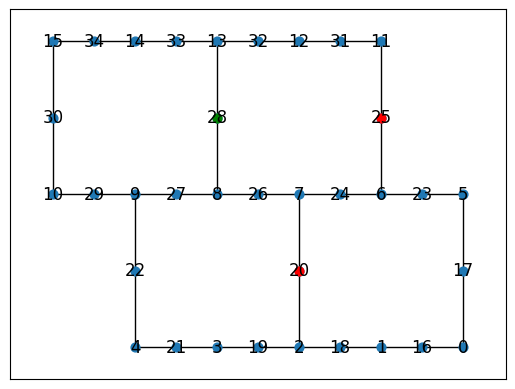

In [6]:
pos = {
    node: (-index_to_name_mapping[node][1], index_to_name_mapping[node][0]) if type(index_to_name_mapping[node][0]) is int 
        else (-(index_to_name_mapping[node][0][1]+index_to_name_mapping[node][1][1])/2, (index_to_name_mapping[node][0][0]+index_to_name_mapping[node][1][0])/2) 
        for node in coupling_graph.nodes
}
nx.draw_networkx(coupling_graph, pos=pos, node_size=40, labels=None)
nx.draw_networkx_nodes(coupling_graph, pos, nodelist=[mapping[x] for x in a_nodes],node_size=40, node_color='red')
nx.draw_networkx_nodes(coupling_graph, pos, nodelist=[mapping[x] for x in b_nodes],node_size=40, node_color='green')

# nx.draw_networkx_nodes(coupling_graph, pos, nodelist=[9,2,4,20,26,22,21,23,3],node_size=60, node_color='black')


In [3]:
mapping = {0: 22, 1: 21, 2: 4, 3: 1, 4: 2, 5: 3, 6: 5, 7: 0, 8: 6, 9: 7, 10: 8, 11: 9}
bad_interactions = [(0, 2, 6), (0, 6, 8), (1, 4, 21), (1, 3, 6), (0, 3, 6), (0, 6, 9), (1, 2, 3, 6), (0, 3, 5, 6), (0, 5, 6, 9), (1, 4, 21, 22), (1, 3, 5), (2, 4, 21), (21, 22)]


In [15]:
clause = np.array([-246, -287, -323, 387, 391])
print( (np.abs(clause) -1) // 35)
print( ((np.abs(clause) - 1) % 35) * np.sign(clause))

[ 7  8  9 11 11]
[ 0 -6 -7  1  5]


In [18]:
clause = np.array([-211, -287, -359])
print( (np.abs(clause) -1) // 35)
print( ((np.abs(clause) - 1) % 35) * np.sign(clause))

[ 6  8 10]
[ 0 -6 -8]


In [14]:
clause = np.array([-246, -287, -359])
print( (np.abs(clause) -1) // 35)
print( ((np.abs(clause) - 1) % 35) * np.sign(clause))

[ 7  8 10]
[ 0 -6 -8]


In [20]:
clause = np.array([-57, -75, -107])
print( (np.abs(clause) -1) // 35)
print( ((np.abs(clause) - 1) % 35) * np.sign(clause))

[1 2 3]
[-21  -4  -1]


In [21]:
clause = np.array([-57, -75, -143])
print( (np.abs(clause) -1) // 35)
print( ((np.abs(clause) - 1) % 35) * np.sign(clause))

[1 2 4]
[-21  -4  -2]


In [24]:
clause = np.array([-216, -246, -287, 352, 358, 362, 367])
print( (np.abs(clause) -1) // 35)
print( ((np.abs(clause) - 1) % 35) * np.sign(clause))

[ 6  7  8 10 10 10 10]
[-5  0 -6  1  7 11 16]


In [22]:
bad_inter = (1, 4, 21, 22)
unmapped = (3, 2, 1, 0)
variables = [35 * unmapped[x] + bad_inter[x] + 1 for x in range(4)]
variables

[107, 75, 57, 23]

In [54]:
swap_1 = tuple((line_node_counters[i], line_node_counters[i + 1]) for i in range(0, len(line_node_counters) - 1, 2))
swap_2 = tuple((line_node_counters[i], line_node_counters[i + 1]) for i in range(1, len(line_node_counters) - 1, 2))
swap_3 = tuple((mapping[a_node], mapping[a_node[0]]) for a_node in a_nodes)
swap_4 = tuple((mapping[b_node], mapping[b_node[0]]) for b_node in b_nodes)

In [55]:
l = len(line_node_counters)
l

60

In [60]:
k = int(l/4 - (l/4 % 8) + 10)
k

18

In [65]:
swap_layers = []
for i in range(k - 7):
    swap_layers.append(swap_1 if i % 2 == 0 else swap_2)
swap_layers.append(swap_4)
for i in range(7):
    swap_layers.append(swap_2 if i % 2 == 0 else swap_1)
swap_layers.append(swap_3)

swap_layers = tuple(swap_layers * 5)

In [77]:
from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration
from qiskit.transpiler.coupling import CouplingMap


In [68]:
coupling_map = CouplingMap(
    list(coupling_graph.edges) + [e[::-1] for e in coupling_graph.edges]
)

In [ ]:
config = AerSimulator._DEFAULT_CONFIGURATION
config["n_qubits"] = len(coupling_graph.nodes)
config = AerBackendConfiguration.from_dict(AerSimulator._DEFAULT_CONFIGURATION)
backend = AerSimulator(configuration=config, coupling_map=coupling_map)

In [81]:
backend.num_qubits

68